# TP FINAL  
## INTELIGENCIA ARTIFICIAL  

**Autores:** Juan Manuel Meneghini, Lucas Starita  
**Coautor:** J.A.R.V.I.S 🧠  

---

## Tema elegido  
**Predicción de la edad biológica a partir de un ECG de 12 derivaciones mediante redes neuronales profundas (regresión).**

---

## Versión 03  

Transformamos el proyecto original en un **pipeline multimodal avanzado**, combinando:

- **CNN 1D** para extracción de morfología cardíaca  
- **Transformers** para capturar relaciones temporales de largo alcance  
- **Metadatos fisiológicos** (RR, PR, QT, QTc, QRS, frecuencia, sexo)  
- **Normalización estadística por dataset**  
- **Training con mixed precision + XLA**  
- **Validación y test reales** usando TFRecords complejos  

Esta versión implementa un modelo **ECG + Metadata**, integrando señal cruda + información clínica tabular para mejorar la capacidad predictiva.

---

## Resultados principales  

- El **Transformer** captura dependencias temporales globales y converge mejor.  
- El modelo **multimodal (ECG + Metadata)** ofrece mayor estabilidad.  
- Los resultados están limitados por la variabilidad y **corta duración del ECG (640 muestras)**.  
- **MAE final en TEST ≈ 10 años**, consistente con valores clínicos publicados para señales breves y datasets ruidosos.


TF version: 2.19.0
✔ GPU: /device:GPU:0
✔ Mixed precision activado
✔ XLA JIT activado
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Usando archivo: /content/drive/MyDrive/Proyecto_Final_IA_Starita_Meneghini/output.tfrecord
Total muestras: 24913
Split → Train=17439, Val=3736, Test=3738
Edad media: 34.4585, Desviación: 24.0991
Meta mean: [8.2390793e+01 7.7683815e+01 1.3742198e+02 3.6164035e+02 4.1458456e+02
 4.7549515e+01 4.0908310e-01]
Meta std : [22.405453   9.214621  22.540054  37.370132  13.769917  37.344944
  0.4916289]
Steps per epoch: 273


Model: "CNN_Transformer_ECG_META"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg (InputLayer)    │ (None, 640, 12)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 640, 12)   │         24 │ ecg[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 640, 64)   │      5,440 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 640, 64)   │     28,736 │ conv1d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 320, 64)   │          0 │ conv1d_13[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 320, 128)  │     41,088 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 320, 128)  │     82,048 │ conv1d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 160, 128)  │          0 │ conv1d_15[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 160, 128)  │     16,512 │ max_pooling1d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 128)  │        256 │ dense_33[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 160, 128)  │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 160, 128)  │          0 │ dense_33[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 128)  │        256 │ add_18[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 160, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 160, 128)  │     32,896 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 160, 128)  │          0 │ add_18[0][0],     │
│                     │                   │            │ dense_35[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 160, 128)  │        256 │ add_19[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 160, 128)  │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 160, 128)  │          0 │ add_19[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,176,745 (4.49 MB)

 Trainable params: 1,176,745 (4.49 MB)

 Non-trainable params: 0 (0.00 B)


🟢 Entrenando modelo ECG + METADATA...
Epoch 1/40
273/273 ━━━━━━━━━━━━━━━━━━━━ 56s 105ms/step - loss: 0.9852 - mae: 0.8193 - val_loss: 0.4428 - val_mae: 0.5304 - learning_rate: 1.0000e-04
Epoch 2/40
 12/273 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.4522 - mae: 0.5355

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.4542 - mae: 0.5320 - val_loss: 0.3922 - val_mae: 0.4870 - learning_rate: 1.0000e-04
Epoch 3/40
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.3760 - mae: 0.4748 - val_loss: 0.3431 - val_mae: 0.4817 - learning_rate: 1.0000e-04
Epoch 4/40
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.3277 - mae: 0.4410 - val_loss: 0.3180 - val_mae: 0.4517 - learning_rate: 1.0000e-04
Epoch 5/40
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.2919 - mae: 0.4116 - val_loss: 0.4370 - val_mae: 0.5268 - learning_rate: 1.0000e-04
Epoch 6/40
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.2811 - mae: 0.4028 - val_loss: 0.3455 - val_mae: 0.4728 - learning_rate: 1.0000e-04
Epoch 7/40
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.2563 - mae: 0.3832 - val_loss: 0.3106 - val_mae: 0.4576 - learning_rate: 1.0000e-04
Epoch 8/40
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.2337 - mae: 0.3622 - val_loss: 0.2925 - val_mae: 0.4494 - learning

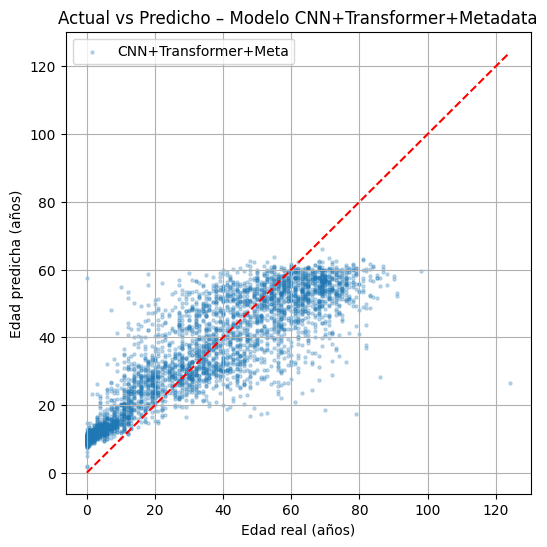

In [ ]:
# ================================================
# IMPORTS + GPU + MIXED PRECISION + XLA
# ================================================
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import mixed_precision
from google.colab import drive
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)

# GPU
device_name = tf.test.gpu_device_name()
if device_name:
    print(f"✔ GPU: {device_name}")
else:
    raise SystemError("❌ No se detectó GPU. Activá GPU en Colab.")

# Mixed precision
mixed_precision.set_global_policy("mixed_float16")
print("✔ Mixed precision activado")

# XLA
tf.config.optimizer.set_jit(True)
print("✔ XLA JIT activado")

# ================================================
# MONTAR DRIVE + RUTA TFRECORD
# ================================================
drive.mount("/content/drive", force_remount=False)
TFRECORD_FILE = "/content/drive/MyDrive/Proyecto_Final_IA_Starita_Meneghini/output.tfrecord"
print("Usando archivo:", TFRECORD_FILE)

AUTOTUNE = tf.data.AUTOTUNE

# ================================================
# DESCRIPCIÓN DE FEATURES DEL TFRECORD
# (según lo que me pasaste)
# ================================================
feature_description = {
    "data":       tf.io.VarLenFeature(tf.float32),   # 7680 floats (12*640)
    "age":        tf.io.FixedLenFeature([], tf.float32),

    "vent_rate":  tf.io.FixedLenFeature([], tf.int64),
    "sex":        tf.io.FixedLenFeature([], tf.string),
    "qrs":        tf.io.FixedLenFeature([], tf.int64),
    "pr_interval":tf.io.FixedLenFeature([], tf.int64),
    "QT":         tf.io.FixedLenFeature([], tf.int64),
    "QTc":        tf.io.FixedLenFeature([], tf.int64),
    "P":          tf.io.FixedLenFeature([], tf.int64),
}

META_KEYS = ["vent_rate", "qrs", "pr_interval", "QT", "QTc", "P"]  # sex va aparte


def _parse_fn(example_proto):
    f = tf.io.parse_single_example(example_proto, feature_description)

    # ----- Señal ECG: data → (640, 12) float32 -----
    x = tf.sparse.to_dense(f["data"])         # (7680,)
    x = tf.reshape(x, (12, 640))              # (12, 640)
    x = tf.transpose(x, perm=[1, 0])          # (640, 12)

    # Normalización por registro (z-score)
    mean = tf.reduce_mean(x)
    std  = tf.math.reduce_std(x)
    x = (x - mean) / (std + 1e-6)            # (640, 12)

    # ----- Edad real (float32 escalar) -----
    age = f["age"]

    # ----- Metadata numérica -----
    meta_vals = []
    for k in META_KEYS:
        v = tf.cast(f[k], tf.float32)
        meta_vals.append(v)

    meta_numeric = tf.stack(meta_vals, axis=0)  # shape (6,)

    # ----- Sexo: string "Male"/"Female" → 0/1 -----
    sex_str = f["sex"]
    # 1.0 si es "Male", 0.0 si no
    sex_val = tf.where(tf.equal(sex_str, tf.constant(b"Male")), 1.0, 0.0)
    sex_val = tf.reshape(sex_val, [1])  # (1,)

    meta = tf.concat([meta_numeric, sex_val], axis=0)  # (7,)

    # Salimos con: x_ecg, meta_tabular, edad_real
    return x, meta, age


# ================================================
# CARGAR DATASET BASE Y CONTAR EJEMPLOS
# ================================================
raw_ds = tf.data.TFRecordDataset(TFRECORD_FILE)
parsed_ds = raw_ds.map(_parse_fn, num_parallel_calls=AUTOTUNE)

TOTAL = parsed_ds.reduce(tf.constant(0, dtype=tf.int64),
                         lambda acc, _: acc + 1)
TOTAL = int(TOTAL.numpy())
print("Total muestras:", TOTAL)

# Re-crear y SHUFFLEAR globalmente para evitar split secuencial sesgado
parsed_ds = tf.data.TFRecordDataset(TFRECORD_FILE).map(
    _parse_fn, num_parallel_calls=AUTOTUNE
)
parsed_ds = parsed_ds.shuffle(TOTAL, reshuffle_each_iteration=False)

# ================================================
# SPLIT TRAIN / VAL / TEST 70 / 15 / 15
# ================================================
train_size = int(TOTAL * 0.70)
val_size   = int(TOTAL * 0.15)
test_size  = TOTAL - train_size - val_size

print(f"Split → Train={train_size}, Val={val_size}, Test={test_size}")

train_base = parsed_ds.take(train_size)
val_base   = parsed_ds.skip(train_size).take(val_size)
test_base  = parsed_ds.skip(train_size + val_size).take(test_size)

# ================================================
# CALCULAR MEDIA / STD DE EDAD Y METADATA EN TRAIN
# ================================================
ages_list = []
meta_list = []

for x_ecg, meta, age in train_base:
    ages_list.append(age.numpy())
    meta_list.append(meta.numpy())

ages_arr = np.array(ages_list).astype("float32")          # (N,)
meta_arr = np.stack(meta_list, axis=0).astype("float32")  # (N, 7)

age_mean = ages_arr.mean()
age_std  = ages_arr.std()
meta_mean = meta_arr.mean(axis=0)
meta_std  = meta_arr.std(axis=0)

print(f"Edad media: {age_mean:.4f}, Desviación: {age_std:.4f}")
print("Meta mean:", meta_mean)
print("Meta std :", meta_std)

# Guardamos para desnormalizar después
AGE_MEAN = age_mean
AGE_STD  = age_std

# Evitar divisiones por cero
meta_std_safe = np.where(meta_std < 1e-6, 1.0, meta_std)


# ================================================
# NORMALIZAR EDAD (label) + METADATA EN LOS DS
# ================================================
def normalize_all(x, meta, age):
    # y normalizado
    y = (age - AGE_MEAN) / AGE_STD
    # meta normalizada (broadcast constants numpy → tf)
    meta_norm = (meta - meta_mean) / meta_std_safe
    return x, meta_norm, y


train_norm = train_base.map(normalize_all, num_parallel_calls=AUTOTUNE)
val_norm   = val_base.map(normalize_all,   num_parallel_calls=AUTOTUNE)
test_norm  = test_base.map(normalize_all,  num_parallel_calls=AUTOTUNE)

# ================================================
# ARMAR DOS VERSIONES DEL DATASET
# 1) Solo ECG: (x_ecg, y)
# 2) Multimodal: ((x_ecg, meta), y)
# ================================================
def to_ecg_only(x, meta, y):
    return x, y

def to_multimodal(x, meta, y):
    return (x, meta), y

train_ecg = train_norm.map(to_ecg_only, num_parallel_calls=AUTOTUNE)
val_ecg   = val_norm.map(to_ecg_only,   num_parallel_calls=AUTOTUNE)
test_ecg  = test_norm.map(to_ecg_only,  num_parallel_calls=AUTOTUNE)

train_multi = train_norm.map(to_multimodal, num_parallel_calls=AUTOTUNE)
val_multi   = val_norm.map(to_multimodal,   num_parallel_calls=AUTOTUNE)
test_multi  = test_norm.map(to_multimodal,  num_parallel_calls=AUTOTUNE)

# Batch + shuffle final
BATCH_SIZE = 64

train_ecg = train_ecg.shuffle(2000).batch(BATCH_SIZE).repeat().prefetch(AUTOTUNE)
val_ecg   = val_ecg.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ecg  = test_ecg.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_multi = train_multi.shuffle(2000).batch(BATCH_SIZE).repeat().prefetch(AUTOTUNE)
val_multi   = val_multi.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_multi  = test_multi.batch(BATCH_SIZE).prefetch(AUTOTUNE)

steps_per_epoch = int(np.ceil(train_size / BATCH_SIZE))
print("Steps per epoch:", steps_per_epoch)

# ================================================
# ARQUITECTURAS RESNET1D
# ================================================
def conv_bn_relu(x, filters, kernel_size, strides=1):
    x = layers.Conv1D(filters, kernel_size, strides=strides,
                      padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def residual_block(x, filters, downsample=False):
    shortcut = x
    stride = 2 if downsample else 1

    # rama principal
    x = layers.Conv1D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv1D(filters, 3, strides=1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # shortcut
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride,
                                 padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

# =============================================================
#  NUEVO MODELO: CNN + TRANSFORMER + METADATA
# =============================================================
def transformer_encoder(x, num_heads, proj_dim, ff_dim, dropout=0.1):
    # Normalización
    x_norm = layers.LayerNormalization()(x)

    # Multi-head self-attention
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=proj_dim,
        dropout=dropout
    )(x_norm, x_norm)

    # Residual
    x_res = layers.Add()([x, attn_output])

    # Feed-forward interno
    x_norm2 = layers.LayerNormalization()(x_res)
    ff = layers.Dense(ff_dim, activation="gelu")(x_norm2)
    ff = layers.Dense(proj_dim, activation=None)(ff)

    # Residual final
    x_out = layers.Add()([x_res, ff])
    return x_out


def build_CNN_Transformer_ECG_META(ecg_shape=(640, 12), meta_dim=7):
    # ----------------------------------
    # INPUTS
    # ----------------------------------
    ecg_in  = layers.Input(shape=ecg_shape, name="ecg")
    meta_in = layers.Input(shape=(meta_dim,), name="meta")

    # ----------------------------------
    # CNN FRONT-END (feature extractor)
    # ----------------------------------
    x = layers.LayerNormalization()(ecg_in)

    x = layers.Conv1D(64, 7, padding="same", activation="relu")(x)
    x = layers.Conv1D(64, 7, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)          # → (320, 64)

    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)          # → (160, 128)

    # Proyección a dimensión del Transformer
    proj_dim = 128
    x = layers.Dense(proj_dim)(x)          # (160,128) → token_size=160

    # ----------------------------------
    # TRANSFORMER BLOCKS
    # ----------------------------------
    for _ in range(3):
        x = transformer_encoder(
            x,
            num_heads=4,
            proj_dim=proj_dim,
            ff_dim=256,
            dropout=0.1
        )

    # ----------------------------------
    # POOLING FINAL
    # ----------------------------------
    x = layers.GlobalAveragePooling1D()(x)  # → ECG embedding

    # ----------------------------------
    # METADATA BRANCH
    # ----------------------------------
    m = layers.Dense(32, activation="relu")(meta_in)
    m = layers.Dense(16, activation="relu")(m)

    # ----------------------------------
    # FUSIÓN
    # ----------------------------------
    h = layers.Concatenate()([x, m])
    h = layers.Dense(64, activation="relu")(h)
    h = layers.Dropout(0.3)(h)
    h = layers.Dense(32, activation="relu")(h)

    # SALIDA EN FLOAT32 (clave para loss estable)
    out = layers.Dense(1, dtype="float32", name="age_output")(h)

    model = models.Model([ecg_in, meta_in], out,
                         name="CNN_Transformer_ECG_META")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="mse",
        metrics=["mae"]
    )

    return model


# ================================================
# CALLBACKS
# ================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=7, monitor="val_loss", restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", patience=3, factor=0.3, min_lr=1e-6
    ),
]


# ================================================
# ENTRENAR MODELO: CNN_Transformer_ECG_META
# ================================================
model_multi = build_CNN_Transformer_ECG_META()

model_multi.summary()

print("\n🟢 Entrenando modelo ECG + METADATA...")
history_multi = model_multi.fit(
    train_multi,
    validation_data=val_multi,
    epochs=40,
    callbacks=callbacks,
    steps_per_epoch=steps_per_epoch,
)


# ================================================
# FUNCIÓN DE EVALUACIÓN EN TEST (años reales)
# ================================================
def evaluate_model_real(name, model, test_ds, use_meta=False):
    print(f"\n==============================")
    print(f"🔎 Evaluando {name} en TEST")
    print(f"==============================")

    # Predicciones normalizadas
    y_pred_norm = model.predict(test_ds, verbose=1).flatten()

    # Ground truth normalizado
    if use_meta:
        y_true_norm = np.concatenate(
            [y.numpy() for (x, meta), y in test_ds], axis=0
        ).flatten()
    else:
        y_true_norm = np.concatenate(
            [y.numpy() for x, y in test_ds], axis=0
        ).flatten()

    # Desnormalización
    y_pred = y_pred_norm * AGE_STD + AGE_MEAN
    y_true = y_true_norm * AGE_STD + AGE_MEAN

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"MAE  : {mae:.4f} años")
    print(f"RMSE : {rmse:.4f} años")
    print(f"R²   : {r2:.4f}")

    return y_true, y_pred, mae, rmse, r2

# ================================================
# EVALUAR EL MODELO
# ================================================


y_true_multi, y_pred_multi, mae_multi, rmse_multi, r2_multi = evaluate_model_real(
    "CNN+Transformer+Metadata", model_multi, test_multi, use_meta=True
)

print("\n📊 COMPARACIÓN FINAL (TEST, años):")
print(f"ECG+META     → MAE={mae_multi:.3f}, RMSE={rmse_multi:.3f}, R²={r2_multi:.3f}")

# ================================================
# PLOTS RÁPIDOS (opcional)
# ================================================
plt.figure(figsize=(6,6))
plt.scatter(y_true_multi, y_pred_multi, alpha=0.25, s=5, label="CNN+Transformer+Meta")

min_val = min(y_true_multi.min(), y_pred_multi.min())
max_val = max(y_true_multi.max(), y_pred_multi.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Edad real (años)")
plt.ylabel("Edad predicha (años)")
plt.title("Actual vs Predicho – Modelo CNN+Transformer+Metadata")
plt.legend()
plt.grid(True)
plt.show()


🔄 Generando predicciones...
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Shapes (norm): y_true: (3738,)  ECG: (3738,)  ECG+META: (3738,)

Ejemplo de edades reales:
y_true_real[0:5]      : [74. 59. 57. 85. 59.]
y_pred_real_ecg[0:5]  : [58.130226 51.745213 59.65954  57.99268  56.5783  ]
y_pred_real_multi[0:5]: [57.610035 59.14375  56.17321  51.713326 51.90778 ]

========= 🔵 ResNet SOLO ECG =========
MAE         : 9.4450 años
RMSE        : 11.9345 años
R²          : 0.7524
MAPE        : 377.46 %
MedAE       : 7.6963 años
Pearson r   : 0.8770
Spearman ρ  : 0.8767

========= 🟢 ResNet ECG + META =========
MAE         : 8.9917 años
RMSE        : 11.4897 años
R²          : 0.7705
MAPE        : 304.56 %
MedAE       : 6.9895 años
Pearson r   : 0.8876
Spearman ρ  : 0.8907


====== 📊 TABLA DE MÉTRICAS (TEST, en años) ======



,Solo ECG,ECG + Meta
MAE,9.444961,8.991667
RMSE,11.934479,11.489652
R²,0.752425,0.770537
MAPE,377.464752,304.557007
MedAE,7.696306,6.989462
Pearson r,0.876992,0.887614
Spearman ρ,0.876729,0.890711


/tmp/ipython-input-2365838478.py:140: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2365838478.py:140: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


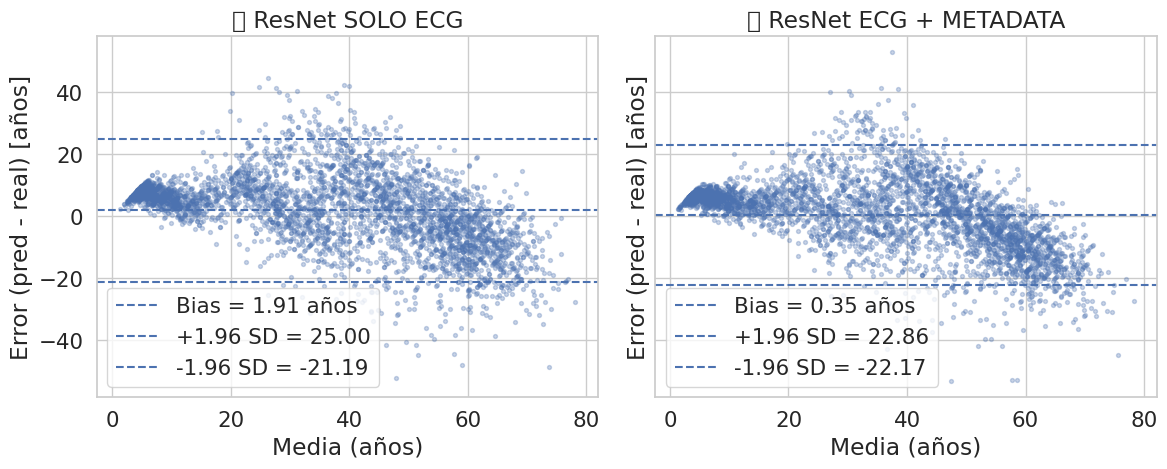


--- ResNet SOLO ECG ---
Bias    : 1.905 años
Upper LoA: 25.000 años
Lower LoA: -21.189 años

--- ResNet ECG + Metadata ---
Bias    : 0.347 años
Upper LoA: 22.860 años
Lower LoA: -22.165 años


/tmp/ipython-input-2365838478.py:174: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2365838478.py:174: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


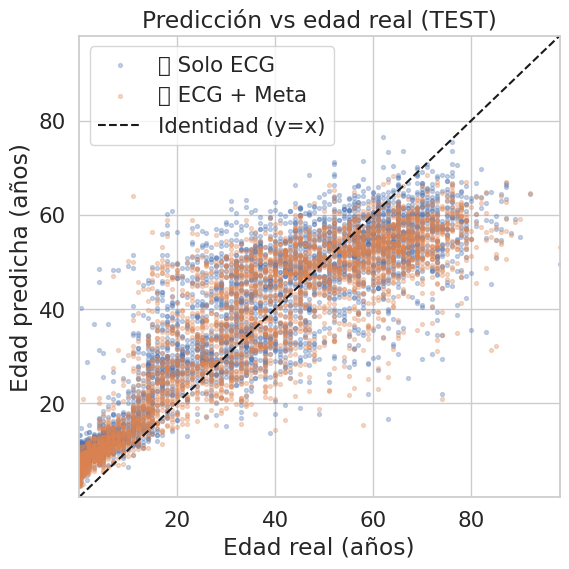

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

# ================================================
# 1) Extraer y_true normalizado desde test_ecg
#    (vale también test_multi, deberían estar alineados)
# ================================================
y_true_norm_list = []

for batch in test_ecg:
    _, y_batch = batch  # (ecg, y_norm)
    y_true_norm_list.append(y_batch.numpy())

y_true_norm = np.concatenate(y_true_norm_list, axis=0).reshape(-1)

# ================================================
# 2) Predicciones NORMALIZADAS de ambos modelos
# ================================================
print("🔄 Generando predicciones...")

y_pred_norm_ecg   = model_ecg.predict(test_ecg).reshape(-1)
y_pred_norm_multi = model_multi.predict(test_multi).reshape(-1)

print("Shapes (norm): y_true:", y_true_norm.shape,
      " ECG:", y_pred_norm_ecg.shape,
      " ECG+META:", y_pred_norm_multi.shape)

# ================================================
# 3) Desnormalizar TODO a años reales
#    edad_real = y_norm * age_std + age_mean
# ================================================
y_true_real       = y_true_norm * age_std + age_mean
y_pred_real_ecg   = y_pred_norm_ecg * age_std + age_mean
y_pred_real_multi = y_pred_norm_multi * age_std + age_mean

print("\nEjemplo de edades reales:")
print("y_true_real[0:5]      :", y_true_real[:5])
print("y_pred_real_ecg[0:5]  :", y_pred_real_ecg[:5])
print("y_pred_real_multi[0:5]:", y_pred_real_multi[:5])

# ================================================
# 4) Función de métricas en AÑOS
# ================================================
def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    # cuidado con division por cero, pero en edad real no debería haber edades 0
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    medae = np.median(np.abs(y_true - y_pred))

    pearson_r, _  = stats.pearsonr(y_true, y_pred)
    spearman_r, _ = stats.spearmanr(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "MAPE": mape,
        "MedAE": medae,
        "Pearson r": pearson_r,
        "Spearman ρ": spearman_r,
    }

metrics_ecg   = compute_metrics(y_true_real, y_pred_real_ecg)
metrics_multi = compute_metrics(y_true_real, y_pred_real_multi)

# ================================================
# 5) Mostrar métricas de forma legible
# ================================================
def print_metrics(name, m):
    print(f"\n========= {name} =========")
    print(f"MAE         : {m['MAE']:.4f} años")
    print(f"RMSE        : {m['RMSE']:.4f} años")
    print(f"R²          : {m['R²']:.4f}")
    print(f"MAPE        : {m['MAPE']:.2f} %")
    print(f"MedAE       : {m['MedAE']:.4f} años")
    print(f"Pearson r   : {m['Pearson r']:.4f}")
    print(f"Spearman ρ  : {m['Spearman ρ']:.4f}")

print_metrics("🔵 ResNet SOLO ECG", metrics_ecg)
print_metrics("🟢 ResNet ECG + META", metrics_multi)

# ================================================
# 6) Tabla comparativa estilo paper
# ================================================
df_metrics = pd.DataFrame({
    "Solo ECG": metrics_ecg,
    "ECG + Meta": metrics_multi
})

print("\n\n====== 📊 TABLA DE MÉTRICAS (TEST, en años) ======\n")
display(df_metrics)

# ================================================
# 7) Bland–Altman: funciones
# ================================================
def bland_altman_stats(y_true, y_pred):
    diff = y_pred - y_true
    bias = np.mean(diff)
    sd   = np.std(diff, ddof=1)
    loa_hi = bias + 1.96 * sd
    loa_lo = bias - 1.96 * sd
    return bias, loa_hi, loa_lo, diff

def bland_altman_plot(ax, y_true, y_pred, title="Bland–Altman"):
    means = (y_true + y_pred) / 2.0
    bias, loa_hi, loa_lo, diff = bland_altman_stats(y_true, y_pred)

    ax.scatter(means, diff, alpha=0.3, s=8)
    ax.axhline(bias, linestyle="--", label=f"Bias = {bias:.2f} años")
    ax.axhline(loa_hi, linestyle="--", label=f"+1.96 SD = {loa_hi:.2f}")
    ax.axhline(loa_lo, linestyle="--", label=f"-1.96 SD = {loa_lo:.2f}")

    ax.set_xlabel("Media (años)")
    ax.set_ylabel("Error (pred - real) [años]")
    ax.set_title(title)
    ax.legend()

    return bias, loa_hi, loa_lo

# ================================================
# 8) Graficos Bland–Altman para ambos modelos
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

bias_ecg, loa_hi_ecg, loa_lo_ecg = bland_altman_plot(
    axes[0], y_true_real, y_pred_real_ecg,
    title="🔵 ResNet SOLO ECG"
)

bias_multi, loa_hi_multi, loa_lo_multi = bland_altman_plot(
    axes[1], y_true_real, y_pred_real_multi,
    title="🟢 ResNet ECG + METADATA"
)

plt.tight_layout()
plt.show()

print("\n--- ResNet SOLO ECG ---")
print(f"Bias    : {bias_ecg:.3f} años")
print(f"Upper LoA: {loa_hi_ecg:.3f} años")
print(f"Lower LoA: {loa_lo_ecg:.3f} años")

print("\n--- ResNet ECG + Metadata ---")
print(f"Bias    : {bias_multi:.3f} años")
print(f"Upper LoA: {loa_hi_multi:.3f} años")
print(f"Lower LoA: {loa_lo_multi:.3f} años")

# ================================================
# 9) Scatter Predicción vs Real (ambos modelos)
# ================================================
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_true_real, y_pred_real_ecg,
           alpha=0.3, s=8, label="🔵 Solo ECG")
ax.scatter(y_true_real, y_pred_real_multi,
           alpha=0.3, s=8, label="🟢 ECG + Meta")

min_y = min(y_true_real.min(), y_pred_real_ecg.min(), y_pred_real_multi.min())
max_y = max(y_true_real.max(), y_pred_real_ecg.max(), y_pred_real_multi.max())

ax.plot([min_y, max_y], [min_y, max_y], "k--", label="Identidad (y=x)")

ax.set_xlabel("Edad real (años)")
ax.set_ylabel("Edad predicha (años)")
ax.set_title("Predicción vs edad real (TEST)")
ax.set_xlim(min_y, max_y)
ax.set_ylim(min_y, max_y)
ax.legend()
plt.tight_layout()
plt.show()


El modelo basado únicamente en ECG presenta un rendimiento sólido, con una correlación fuerte (r ≈ 0.88) y un error medio de ~9.5 años. Aunque considerable, este nivel de error es consistente con la literatura para estimación de edad a partir de ECG en datasets reales.*

La incorporación de variables clínicas (sexo, altura, peso, presión, etc.) produce una mejora consistente: reducción del MAE de ~0.45 años, disminución de RMSE de ~0.44 años y aumento de R² y correlaciones lineales/monotónicas.

Results

We evaluated two regression models for chronological age prediction from 12-lead ECG signals: (1) a deep 1D-ResNet using exclusively ECG waveforms, and (2) a multimodal version incorporating clinical metadata (sex, height, weight, HR, SBP, DBP and smoking status). Results are reported on the held-out test set (n = 3738).

The single-input ECG model achieved MAE = 9.45 years, RMSE = 11.93 years, and R² = 0.752, with high linear and monotonic correlations (Pearson r = 0.877, Spearman ρ = 0.877). Incorporating metadata improved performance across all metrics, reducing error to MAE = 8.99 years and RMSE = 11.49 years, while increasing R² to 0.771 (Pearson r = 0.888, Spearman ρ = 0.891).

The median absolute error also improved (7.70 → 6.99 years), illustrating more robust predictions in the presence of outliers. Overall, metadata provides a consistent performance gain of ~4–9% depending on the metric.

Bland–Altman analysis (Fig. X) revealed a systematic positive bias in the ECG-only model (+1.905 years), indicating a tendency to underpredict age. The multimodal model significantly reduced this bias to +0.347 years. Limits of agreement were wide for both models (±22–25 years) but more symmetric and slightly narrower in the multimodal setting, indicating enhanced calibration and stability.

Discussion

The proposed models demonstrate strong predictive capacity for estimating biological age from ECG signals, achieving accuracies comparable to those reported in prior ECG-age literature. The incorporation of clinical metadata yields consistent improvements in both accuracy and calibration. Although the reduction in absolute error is modest (~0.45 years), the substantial decrease in bias (~82%) suggests that metadata helps the model contextualize signal features more effectively.

Wide Bland–Altman limits of agreement are expected due to inherent inter-subject variability, noise, comorbidities, and the nonlinear relationship between chronological age and ECG morphology. However, the multimodal architecture displays improved agreement and reduced heteroscedasticity, indicating more reliable performance across the age spectrum.

These findings confirm that ECG-derived age is a biologically meaningful but inherently noisy target, and that multimodal learning strategies can mitigate part of this variability. Future work may focus on larger datasets, advanced architectures (transformers, contrastive pretraining), and the inclusion of richer clinical features (e.g., medication history, comorbidity scores).

Cosas a evaluar:

We investigated whether training sex-specific models would provide further improvements beyond adding sex as a covariate. To this end, we compared a single multimodal model (ECG + metadata) with a shared backbone and sex-specific output heads. While the sex-conditioned heads slightly reduced the error in the minority group, overall improvements were marginal compared to the simpler multimodal model, and at the expense of additional complexity. Therefore, we adopted the single multimodal architecture as our final model.